In [28]:
# ===============================
# Import Required Libraries
# ===============================

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Model evaluation metrics
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

# Statistical analysis
from scipy import stats

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

#Improve the Appearance of Graphs
# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")

# Set default color palette
sns.set_palette("husl")

In [ ]:
task 1

In [29]:
# Load Auto MPG Dataset
oilSales = pd.read_csv('oil_sales_assignment_dataset.csv')
print("Dataset loaded successfully from URL!")

Dataset loaded successfully from URL!


In [30]:
oilSales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.3+ KB


In [31]:
# first five rows
oilSales.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


In [32]:
# the last 5 rows
oilSales.tail()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
1995,TABUK,HM No 99317 GS-CENTER-TABUK MAIN RD TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,LARA COCONUT 0.5L PREMIUM,31-40,2024,11,74.4,2.4,31.0
1996,AL AHSA,HM No 85390 GS-CENTER-AL AHSA MAIN RD AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,LARA SUNFLOWER 3L,31-40,2022,5,20.0,0.5,40.0
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.8,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.0,5.0,61.0
1999,JEDDAH,HM No 73689 GS-CENTER-JEDDAH MAIN RD JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,BAYTNA COCONUT 1.8L ECO,101+,2022,4,181.8,1.8,101.0


Task 2
Answer the following:
1. How many rows are there?
  - 2000
2. How many columns?
  - 13
3. Which columns are numerical?
year           
  -  month ,value_sales ,volume_sales , average_price  
4. Which columns are categorical?
  - city , store_name , manufacturer, brand , class , size , sku ,price_bracket  

Task 3

In [33]:
# Check for missing values.
oilSales.isnull().sum()


city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64

Are there any missing values?
 - no

Task 4

In [34]:
oilSales.describe()

,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


In [ ]:
Part 2: Data Preparation

In [35]:
# Create a LabelEncoder instance
encoder = LabelEncoder()

# List of columns to encode
columns_to_encode = ["city",  "manufacturer", "brand", "class", "size", "price_bracket"]
encoded_column_names = ["En_city", "En_manufacturer", "En_brand", "En_class", "En_size", "En_price_bracket"]

for original_col, encoded_col in zip(columns_to_encode, encoded_column_names):
    if original_col in oilSales.columns:
        oilSales[encoded_col] = encoder.fit_transform(oilSales[original_col])

Part 3: Univariate Linear Regression

In [38]:
# task 1 - Select Features
x= oilSales[['average_price']]  # independent variable
y= oilSales['value_sales']  # target variable

#task 2: Split the Dataset - 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
x,
y,
test_size=0.20,
random_state=42
)

#task 3: Train the Model
model = LinearRegression() # creating the model
model.fit(x_train, y_train) # fit() -learns the best straight line y= b1x + b0

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
# task 4: View the Equation
intercept = model.intercept_
coefficient = model.coef_[0]
print ("Therefore, sales = - 27.28 + 10.51 × average_price") 

#Task 5
print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")
print ("For every one-unit increase in average price ,the predicted value sales increases by approximately 10.51.")

Therefore, sales = - 27.28 + 10.51 × average_price
Intercept : -27.28
Coefficient : 10.51
For every one-unit increase in average price ,the predicted value sales increases by approximately 10.51.


In [47]:
# training the model
train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

# Step 6: Evaluate the Model
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print ("The closer predictions are to actual values, the lower the RMSE.")
print(f'Training RMSE = {train_rmse}')
print(f'Testing RMSE = {test_rmse}')
print ("\nR2 measures how much variation in value sales is explained by the model.")
print(f'Training R2 = {train_r2}')
print(f'Testing R2 = {test_r2}')

The closer predictions are to actual values, the lower the RMSE.
Training RMSE = 687.8606680243196
Testing RMSE = 674.0336191200048

R2 measures how much variation in value sales is explained by the model.
Training R2 = 0.1734909078761384
Testing R2 = 0.13802212065425412


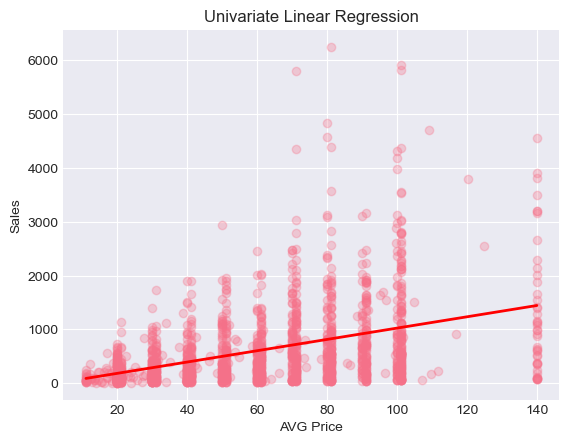

In [49]:
#Step 7: scatter plot with Regression Line

plt.scatter(x_train, y_train, alpha=0.3)

x_sorted = x_train.sort_values("average_price")
y_sorted = model.predict(x_sorted)

plt.plot(
x_sorted,
y_sorted,
color="red",
linewidth=2
)

plt.xlabel("AVG Price")
plt.ylabel("Sales")
plt.title("Univariate Linear Regression")
plt.show()

In [54]:
# Part 4: Multivariate Linear Regression
# Task 1 Prepare the feature matrix.
features = [ "year" , "month" , "volume_sales" ,  "average_price", "En_city" , "En_manufacturer" ,"En_brand" ,"En_class", "En_size" , "En_price_bracket" ]
x = oilSales[features]
y = oilSales["value_sales"]

# task 2: Split the Dataset
x_mtrain, x_mtest, y_mtrain, y_mtest = train_test_split(
x,
y,
test_size=0.20,
random_state=42
)

In [56]:
# task 3: Standardize Features
scaler = StandardScaler()
x_mtrain = scaler.fit_transform(x_mtrain)
x_mtest = scaler.transform(x_mtest)

# task 4: Train the Model
model = LinearRegression()
model.fit(x_mtrain, y_mtrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
# task 5: Display intercept
Intercepts = pd.DataFrame({
"Feature": features,
"Intercept": model.intercept_
})

Intercepts["Absolute"] = Intercepts["Intercept"].abs()

Intercepts.sort_values(
"Absolute",
ascending=False,
inplace=True
)

print(Intercepts)

            Feature   Intercept    Absolute
0              year  617.128994  617.128994
1             month  617.128994  617.128994
2      volume_sales  617.128994  617.128994
3     average_price  617.128994  617.128994
4           En_city  617.128994  617.128994
5   En_manufacturer  617.128994  617.128994
6          En_brand  617.128994  617.128994
7          En_class  617.128994  617.128994
8           En_size  617.128994  617.128994
9  En_price_bracket  617.128994  617.128994


In [60]:
# task 6: Display Feature Importance
coefficients = pd.DataFrame({
"Feature": features,
"Coefficient": model.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
"Absolute",
ascending=False,
inplace=True
)

print(coefficients)

            Feature  Coefficient    Absolute
2      volume_sales   626.813697  626.813697
3     average_price   295.727899  295.727899
4           En_city    10.434005   10.434005
9  En_price_bracket    -9.404697    9.404697
1             month    -8.373249    8.373249
7          En_class    -6.081919    6.081919
5   En_manufacturer     2.736010    2.736010
8           En_size    -1.912599    1.912599
6          En_brand     1.801398    1.801398
0              year     0.425809    0.425809


In [61]:
# Step 7: Make Predictions
train_predictions = model.predict(x_mtrain)
test_predictions = model.predict(x_mtest)

# Step 8: Evaluate the Model
train_rmse_multi = np.sqrt(
mean_squared_error(y_mtrain, train_predictions)
)

test_rmse_multi = np.sqrt(
mean_squared_error(y_mtest, test_predictions)
)

train_r2_multi = r2_score(y_mtrain, train_predictions)

test_r2_multi = r2_score(y_mtest, test_predictions)

print(f'Training RMSE = {train_rmse_multi}')
print(f'Testing RMSE = {test_rmse_multi}')
print(f'Training R2 = {train_r2_multi}')
print(f'Testing R2 = {test_r2_multi}')

Training RMSE = 283.5217729970596
Testing RMSE = 296.5379627814597
Training R2 = 0.8595830571686012
Testing R2 = 0.8331625271287663


Part 5: Model Comparison

In [62]:
comparison = pd.DataFrame({
"Model": [
"Univariate (AVG Price)",
"Multivariate (All Features)"
],
"Train RMSE": [train_rmse, train_rmse_multi],
"Test RMSE": [test_rmse, test_rmse_multi],
"Train R²": [train_r2, train_r2_multi],
"Test R²": [test_r2, test_r2_multi]
})
print("Model Performance Comparison")
print(comparison.round(2))

Model Performance Comparison
                         Model  Train RMSE  Test RMSE  Train R²  Test R²
0       Univariate (AVG Price)      687.86     674.03      0.17     0.14
1  Multivariate (All Features)      283.52     296.54      0.86     0.83


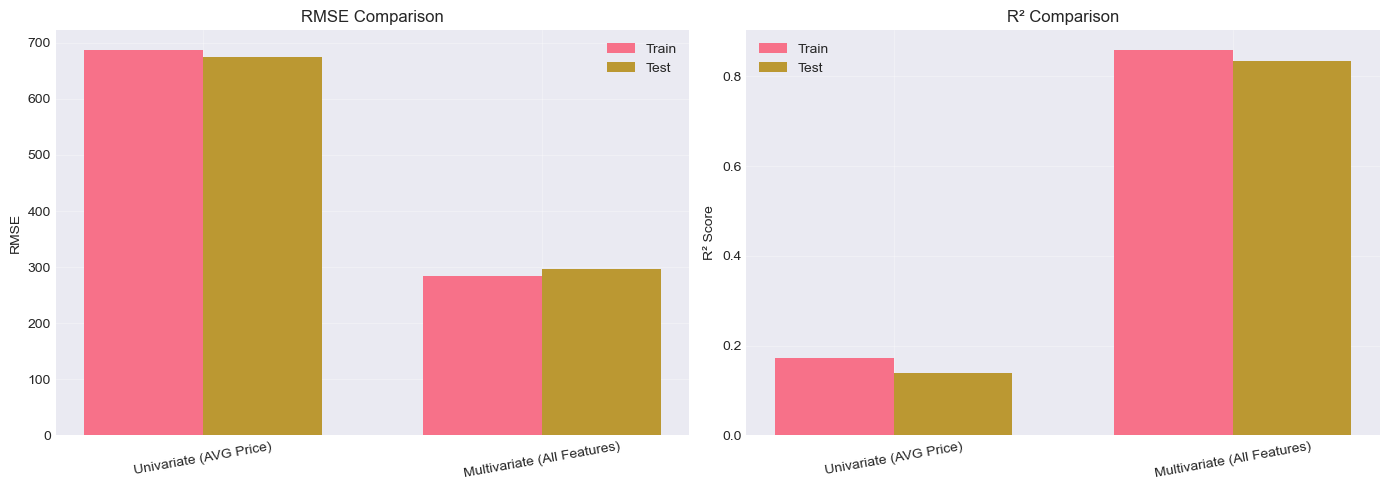

In [63]:
# Visual Comparison using bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison["Model"]
x = np.arange(len(models))
width = 0.35
# -----------------------------
# RMSE Comparison
# -----------------------------
axes[0].bar(
    x - width/2,
    comparison["Train RMSE"],
    width,
    label="Train"
)
axes[0].bar(
    x + width/2,
    comparison["Test RMSE"],
    width,
    label="Test"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)
# -----------------------------
# R² Comparison
# -----------------------------
axes[1].bar(
    x - width/2,
    comparison["Train R²"],
    width,
    label="Train"
)
axes[1].bar(
    x + width/2,
    comparison["Test R²"],
    width,
    label="Test"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=10)
axes[1].set_ylabel("R² Score")
axes[1].set_title("R² Comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Part 6: Interpretation Questions
Discuss the following questions with your group.
Question 1
Which model performed better?
 - multivariate
Why?
 - Using multiple features significantly improves prediction accuracy
Question 2
Why is the Multivariate model expected to perform better than the Univariate model?
 - its prediction accuracy is higher and the prediction error decreased more than by half than the univariat


In [69]:
# Question 3
# Which feature appears to have the greatest influence on sales?
 #- its on volume sales
# Support your answer using the coefficient table.
print ( f" Greatest influence on sales(value sales) = {coefficients['Coefficient'].max()} ")

 Greatest influence on sales(value sales) = 626.8136973467748 


Question 4
What does a negative coefficient mean?
 - its predicting less than the actual sales value
Question 5
If the R2 score is 0.82,
what does this tell us about the model?
  - its covering 82% of the predicting variation